# Session 38: Classification Model Leaderboard Comparison
Consolidating and visualizing the performance metrics across all implemented classification algorithms for at-risk student prediction.

In [3]:
from pathlib import Path
import pandas as pd

# 1. Define file paths
PROJECT_ROOT = Path.cwd().resolve()
for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (parent / ".git").exists():
        PROJECT_ROOT = parent
        break

input_table_path = PROJECT_ROOT / "reports" / "tables" / "classification_model_comparison.csv"
leaderboard_output_path = PROJECT_ROOT / "reports" / "classification_leaderboard.csv"

# Ensure reports directory exists
leaderboard_output_path.parent.mkdir(parents=True, exist_ok=True)

# 2. Load the cumulative metrics
df = pd.read_csv(input_table_path)

# 3. Sort strictly by F1 score in descending order (highest F1 first)
leaderboard = df.sort_values(by="f1", ascending=False).reset_index(drop=True)

# 4. Assign structural Rank starting at 1
if "Rank" in leaderboard.columns:
    leaderboard = leaderboard.drop(columns=["Rank"])
leaderboard.insert(0, "Rank", range(1, len(leaderboard) + 1))

# 5. Export to CSV
leaderboard.to_csv(leaderboard_output_path, index=False)

print(f"Successfully exported leaderboard to: {leaderboard_output_path}")
display(leaderboard)

Successfully exported leaderboard to: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/classification_leaderboard.csv


,Rank,Overall F1 Rank,Model,Full Model Name,Model Family,Scaling_Used,accuracy,precision,recall,f1,roc_auc,at_risk_precision,at_risk_recall,at_risk_f1
0,1,1,DTC,Decision Tree Classifier,Tree-based,False,0.911392,0.857143,0.888889,0.872727,0.909900,0.941176,0.923077,0.932039
1,2,2,LR,Logistic Regression,Linear,True,0.898734,0.827586,0.888889,0.857143,0.973647,0.827586,0.888889,0.857143
2,3,3,RFC,Random Forest Classifier,Ensemble,False,0.898734,0.827586,0.888889,0.857143,0.960470,0.940000,0.903846,0.921569
3,4,4,AdaBoost,AdaBoost Classifier,Boosting,False,0.898734,0.851852,0.851852,0.851852,0.972934,0.923077,0.923077,0.923077
4,5,5,GradBoost,Gradient Boosting Classifier,Boosting,False,0.860759,0.785714,0.814815,0.800000,0.960826,0.901961,0.884615,0.893204
5,6,6,MLPC,Multi-Layer Perceptron Classifier,Neural Network,True,0.873418,0.869565,0.740741,0.800000,0.942308,0.875000,0.942308,0.907407
6,7,7,SVM,Support Vector Machine,Maximum-margin,True,0.835443,0.791667,0.703704,0.745098,0.938746,0.854545,0.903846,0.878505
7,8,8,NB,Gaussian Naive Bayes,Probabilistic,True,0.822785,0.760000,0.703704,0.730769,0.900285,0.851852,0.884615,0.867925
8,9,9,KNN,K-Nearest Neighbors,Instance-based,True,0.746835,0.705882,0.444444,0.545455,0.739316,0.758065,0.903846,0.824561


In [4]:
winner = leaderboard.iloc[0]
winner_name = str(winner["Model"])
winner_f1 = float(winner["f1"])

print("Classification Algorithm Winner")
print("-------------------------------")
print(f"Model:    {winner_name}")
print(f"F1 Score: {winner_f1:.4f}")

Classification Algorithm Winner
-------------------------------
Model:    DTC
F1 Score: 0.8727


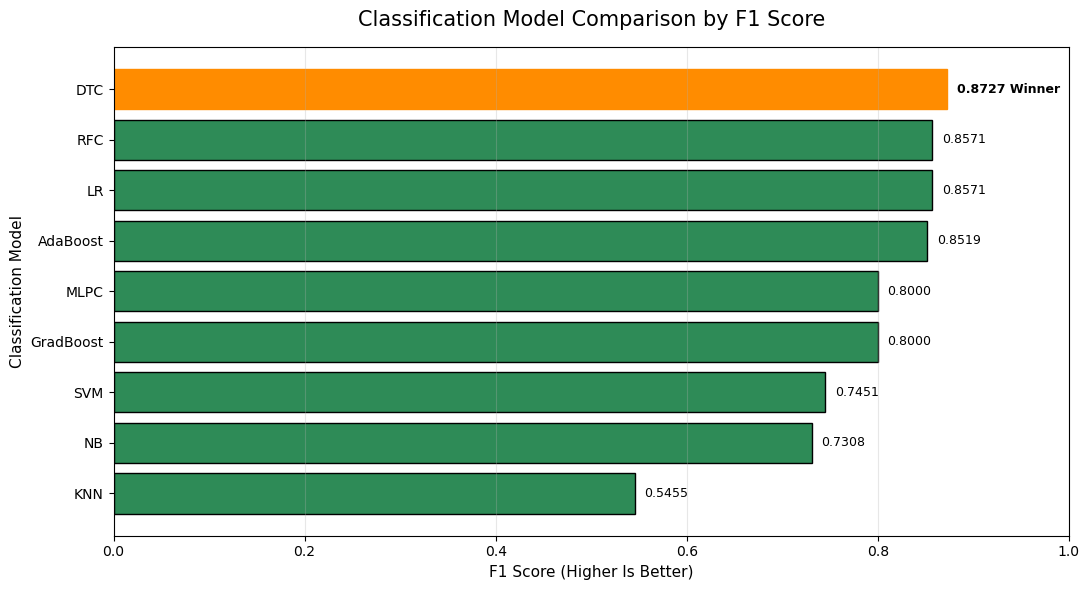

Comparison figure exported successfully to: ../figures/classification_f1_comparison.png


In [5]:
# Arrange data such that the highest-performing model sits at the top
chart_data = leaderboard.sort_values(by="f1", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, max(6, len(chart_data) * 0.60)))
bars = ax.barh(chart_data["Model"], chart_data["f1"], color="seagreen", edgecolor="black")

# Add layout detailing
ax.set_title("Classification Model Comparison by F1 Score", fontsize=15, pad=15)
ax.set_xlabel("F1 Score (Higher Is Better)", fontsize=11)
ax.set_ylabel("Classification Model", fontsize=11)
ax.set_xlim(0, 1.0)
ax.grid(axis="x", alpha=0.3)

# Annotate each bar directly with its evaluation value
for bar, model_name, f1_value in zip(bars, chart_data["Model"], chart_data["f1"]):
    label = f"{f1_value:.4f}"
    if str(model_name) == winner_name:
        label += " Winner"
        bar.set_color("darkorange")  # Highlight winner visually
    
    ax.text(
        bar.get_width() + 0.01, 
        bar.get_y() + bar.get_height() / 2, 
        label, 
        va="center", 
        fontsize=9, 
        fontweight="bold" if str(model_name) == winner_name else "normal"
    )

plt.tight_layout()

# Save high-resolution chart asset locally
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Comparison figure exported successfully to: {figure_path}")